# Calculating regional tsunami travel times, a Cascadia example

Ray-traced tsunami travel times for a hypothetical megathrust rupture on the
Cascadia subduction zone, offshore Washington state. In this notebook we will first
calculate the rays fanning out from a hypothetical source then find the minimum
arrival time on a regular grid in order to make a travel times map.

Note that in order to make very high resolution map you will need to fan the rays out
with very fine azimuthal spacing so there is a trade off between the level of detail 
in the map and the computational cost (though it's not that onerous).

**Source:** 47.86°N, 124.91°W — consistent with the locked zone of the Cascadia megathrust.

**Bathymetry:** GEBCO-derived 30 arc-second grid (`data/cascadia.xyz`).

> **Note:** this notebook requires `scipy` and `pandas` in addition to the core
> TsunamiTrace dependencies.  Install with `pip install scipy pandas`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import griddata, RegularGridInterpolator
from scipy.stats import binned_statistic_2d
import TsunamiTrace as tt
%matplotlib inline

## Load bathymetry

`tt.load_bathymetry` reads the three-column ASCII file, validates the regular grid,
and returns depth in the `trace_rays` convention (positive = ocean).
The cascadia file uses the standard geographic convention (negative = ocean),
so the default `negate=True` is what we want.

In [2]:
print('Loading data/cascadia.xyz …', end='', flush=True)
lon_arr, lat_arr, depth_tracing = tt.load_bathymetry('../data/cascadia.xyz')
n_lon, n_lat = depth_tracing.shape
lon_full     = lon_arr
lat_full     = lat_arr
print(f' done.')

print(f'Grid   : {n_lon} × {n_lat}  '
      f'(spacing {lon_arr[1]-lon_arr[0]:.4f}°)')
print(f'Lon    : {lon_arr[0]:.3f} – {lon_arr[-1]:.3f}°')
print(f'Lat    : {lat_arr[0]:.3f} – {lat_arr[-1]:.3f}°')
print(f'Depth  : 0 – {depth_tracing.max():.0f} m  (ocean only; land zeroed)')

# depth_grid for plotting: (n_lat, n_lon), geographic sign (negative = ocean)
depth_grid = -depth_tracing.T

Loading data/cascadia.xyz … done.
Grid   : 1080 × 1560  (spacing 0.0083°)
Lon    : -131.996 – -123.004°
Lat    : 39.004 – 51.996°
Depth  : 0 – 5191 m  (ocean only; land zeroed)


## Bathymetry and topography, plot to check it looks good

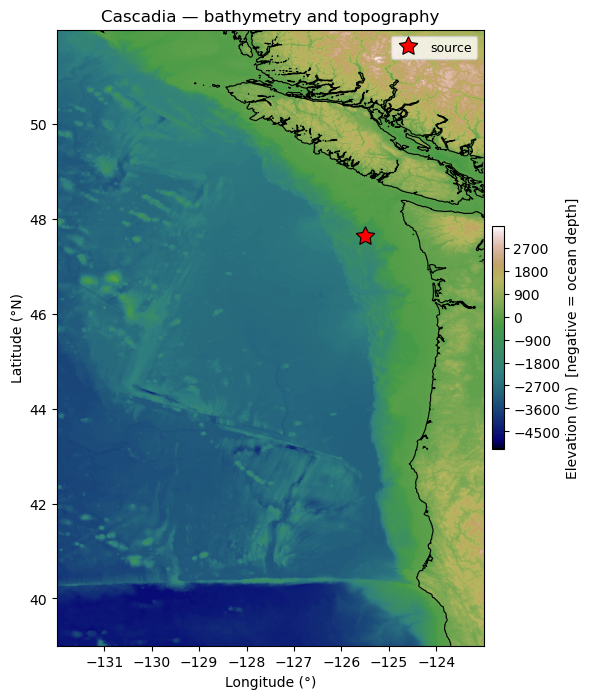

In [3]:
SOURCE_LON = -125.5
SOURCE_LAT =   47.65

vmin = float(np.nanmin(depth_grid))
vmax = float(np.nanmax(depth_grid))
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))

fig, ax = plt.subplots(figsize=(6, 9))

cf = ax.contourf(lon_full, lat_full, depth_grid,
                 levels=200, cmap='gist_earth', norm=norm)

# Coastline at sea level
ax.contour(lon_full, lat_full, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (\u00b0)')
ax.set_ylabel('Latitude (\u00b0N)')
ax.set_title('Cascadia \u2014 bathymetry and topography')
ax.set_aspect('equal')
ax.legend(fontsize=9)

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Elevation (m)  [negative = ocean depth]')
plt.tight_layout()
plt.show()

## Tsunami ray tracing

Fan rays at a small azimuth spacing from the source and integrate for 3 hours.
The dense ray fan ensures good geographic coverage for the first-arrival binning step.

In [4]:
DT           =  180.0                        # integration time step, seconds
MAX_TIME     = 2.5 * 3600.0                    # maximum integration time, seconds
DELTA_DEG = 1e-3
AZIMUTHS_DEG = np.arange(0, 360, DELTA_DEG, dtype=float)

print(f'Source   : {SOURCE_LON}°E, {SOURCE_LAT}°N')
print(f'Rays     : {len(AZIMUTHS_DEG)}  (every {AZIMUTHS_DEG[1]-AZIMUTHS_DEG[0]:.3f}°)')
print(f'dt       : {DT:.0f} s    max time : {MAX_TIME/3600:.0f} h')
print(f'Tracing …', end='', flush=True)

ray_lon, ray_lat, _ = tt.trace_rays(
    lon_arr, lat_arr, depth_tracing,
    DT, MAX_TIME,
    SOURCE_LON, SOURCE_LAT,
    AZIMUTHS_DEG,
)

n_done = int(np.sum(~np.isnan(ray_lon[:, -1])))
print(f'  done.  {n_done}/{len(AZIMUTHS_DEG)} rays reached max_time.')

Source   : -125.5°E, 47.65°N
Rays     : 360000  (every 0.001°)
dt       : 180 s    max time : 2 h
Tracing …  done.  7597/360000 rays reached max_time.


## Compute the travel time map

`tt.grid_travel_times` bins every ray position onto a regular grid, keeping
the minimum (first-arrival) time in each cell.  Empty ocean bins are filled
by linear interpolation from neighbouring filled cells (`fill=True`).

In [5]:
# Travel-time grid resolution — independent of the bathymetry grid (0.0083°).
# Coarser bins give denser ray coverage per cell and fewer empty-bin gaps;
# finer bins resolve more spatial detail but need more rays to fill.
# Rule of thumb: BIN_DEG ≈ 10–20× the bathymetry spacing is a good starting point.
BIN_DEG = 0.1

print('Gridding travel times …', end='', flush=True)
lon_bin, lat_bin, travel_time = tt.grid_travel_times(
    ray_lon, ray_lat, DT,
    lon_arr, lat_arr, depth_tracing,
    bin_deg=BIN_DEG,
)
print(f' done.  Output grid: {len(lon_bin)} × {len(lat_bin)}')


Gridding travel times … done.  Output grid: 91 × 131


## Let's make a map of all the rays

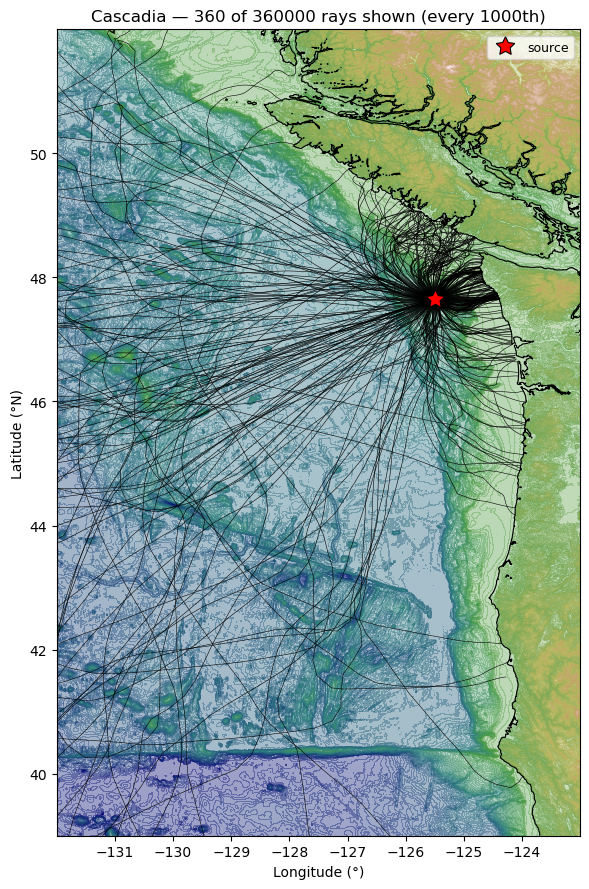

In [6]:
PLOT_EVERY_N = 1000  # plot every Nth ray — increase to declutter, 1 = all rays

fig, ax = plt.subplots(figsize=(6, 9))

# Muted bathymetry background
ax.contourf(lon_full, lat_full, depth_grid,
            levels=200, cmap='gist_earth', norm=norm, alpha=0.4)
ax.contour(lon_full, lat_full, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Ray paths (decimated)
for i in range(0, ray_lon.shape[0], PLOT_EVERY_N):
    ax.plot(ray_lon[i], ray_lat[i], color='black', linewidth=0.4, alpha=1)

# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'Cascadia — {ray_lon.shape[0] // PLOT_EVERY_N} of {ray_lon.shape[0]} rays shown '
    f'(every {PLOT_EVERY_N}th)'
)
ax.set_xlim([lon_full.min(),lon_full.max()])
ax.set_ylim([lat_full.min(),lat_full.max()])
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Now let's make a map of the travel times proper

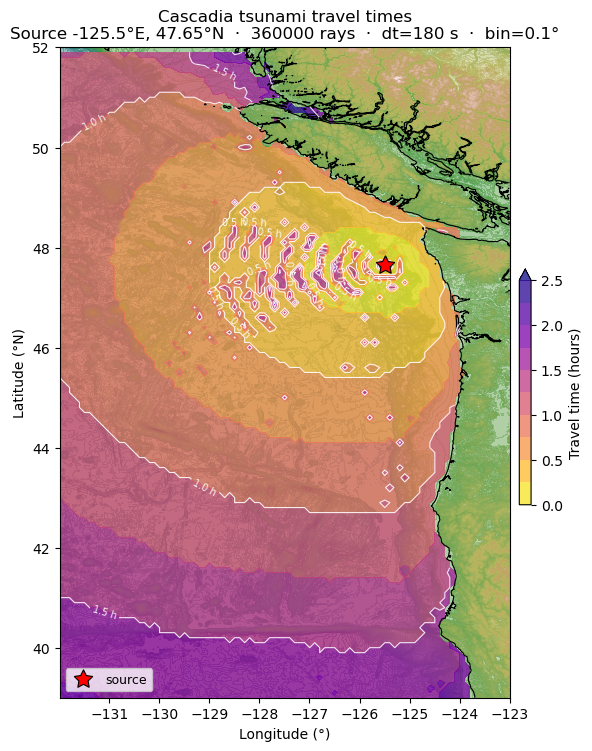

In [7]:
fig, ax = plt.subplots(figsize=(6, 9))

# Full-resolution bathymetry background
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))
ax.contourf(lon_full, lat_full, depth_grid,
            levels=200, cmap='gist_earth', norm=norm, alpha=0.5)
ax.contour(lon_full, lat_full, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Travel time — filled contours on the coarser BIN_DEG grid
tt_max = MAX_TIME / 3600
cf = ax.contourf(lon_bin, lat_bin, travel_time,
                 levels=np.arange(0, tt_max + 0.25, 0.25),
                 cmap='plasma_r', alpha=0.75, extend='max')

# Isochrone lines every 30 minutes
cs = ax.contour(lon_bin, lat_bin, travel_time,
                levels=np.arange(0.5, tt_max + 0.5, 0.5),
                colors='white', linewidths=0.8, alpha=0.9)
ax.clabel(cs, fmt='%.1f h', fontsize=7, inline=True)

# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'Cascadia tsunami travel times\n'
    f'Source {SOURCE_LON}°E, {SOURCE_LAT}°N  ·  '
    f'{len(AZIMUTHS_DEG)} rays  ·  dt={DT:.0f} s  ·  bin={BIN_DEG}°'
)
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='lower left')

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Travel time (hours)')
plt.tight_layout()
plt.show()

That looks okish. The times look generally correct but there's strange "stipling" due west from the source with slower travel times that don't seem to correlate with the udnerlying bathymetry. This could be that there are cells that get no rays and are interpolated over. Though i don't think that's the cause. But let's chase that down, we can check for this by plotting the ray results and keeping cells with no times as NaNs and not coloring them.

We call `grid_travel_times()`as before but pass in `fill=False` to keep empty cells as `NaN`

In [8]:
# This is the exact same function call as before but without gap-filling to expose ray coverage directly
_, _, travel_time_raw = tt.grid_travel_times(
    ray_lon, ray_lat, DT,
    lon_arr, lat_arr, depth_tracing,
    bin_deg=BIN_DEG, fill=False,
)

n_ocean  = int(np.sum(~np.isnan(travel_time)))
n_direct = int(np.sum(~np.isnan(travel_time_raw)))
print(f'Ray coverage    : {n_direct}/{n_ocean} ocean bins hit directly '
      f'({100 * n_direct / max(n_ocean, 1):.0f}%)')

Ray coverage    : 9225/9265 ocean bins hit directly (100%)


## Travel time map — raw ray coverage (no gap-filling)

Same binning as above but with `fill=False`: a cell is coloured only if at least
one ray actually passed through it.  Grey ocean cells received no ray it could be they sit
in a geometric shadow zone behind a peninsula or island, that we didn't shoot enough rays or the wave simply has
not arrived within `MAX_TIME`.  This view is useful for deciding whether to
increase azimuth density or `MAX_TIME`, and for identifying artefacts that
gap-filling may have smoothed over.

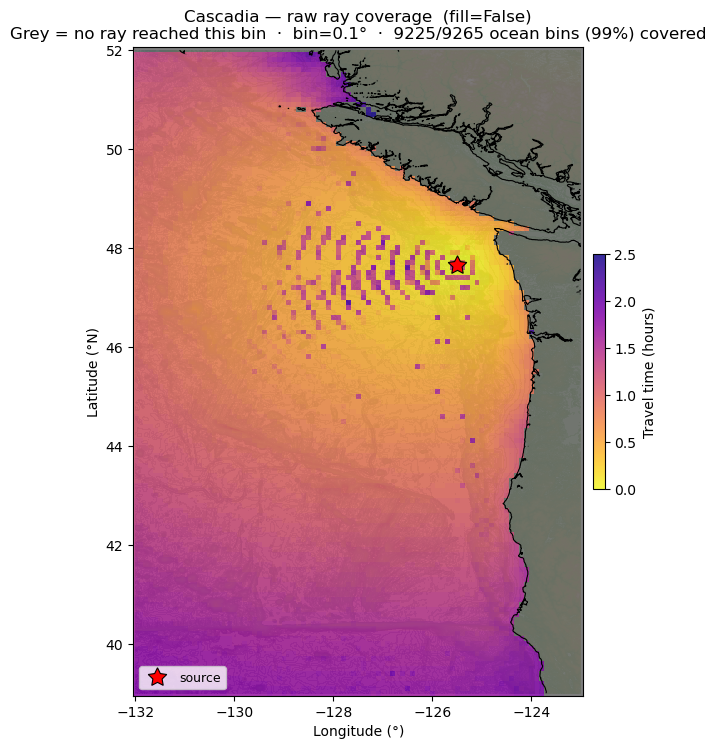

In [9]:
import copy

fig, ax = plt.subplots(figsize=(6, 9))

# Bathymetry background
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))
ax.contourf(lon_full, lat_full, depth_grid,
            levels=200, cmap='gist_earth', norm=norm, alpha=0.5)
ax.contour(lon_full, lat_full, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# pcolormesh maps each bin cell directly — no interpolation across gaps.
# set_bad paints NaN cells (shadow zones and land) in grey so they are
# immediately visible rather than showing the bathymetry background through.
cmap_raw = copy.copy(plt.cm.plasma_r)
cmap_raw.set_bad(color='0.40')   # medium-dark grey
norm_tt  = mcolors.Normalize(vmin=0, vmax=MAX_TIME / 3600)

pcm = ax.pcolormesh(lon_bin, lat_bin, travel_time_raw,
                    cmap=cmap_raw, norm=norm_tt,
                    shading='nearest', alpha=0.85)

# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'Cascadia — raw ray coverage  (fill=False)\n'
    f'Grey = no ray reached this bin  ·  bin={BIN_DEG}°  ·  '
    f'{n_direct}/{n_ocean} ocean bins ({100*n_direct//max(n_ocean,1)}%) covered'
)
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='lower left')

cbar = fig.colorbar(pcm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Travel time (hours)')
plt.tight_layout()
plt.show()

Ok well the stipling is not due to NaNs. Let's plot the rays on top of the travel map and see if there's any wisdom

## Same map as before but combining travel times and rays

/var/folders/5x/5xtm6r7126g41vdgwb462xp40000gn/T/ipykernel_65508/425145274.py:34: UserWarning: Adding colorbar to a different Figure <Figure size 600x900 with 2 Axes> than <Figure size 600x900 with 2 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)


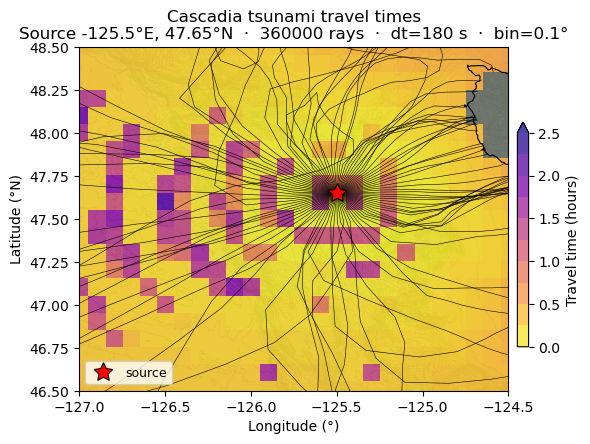

In [10]:
fig, ax = plt.subplots(figsize=(6, 9))

# Full-resolution bathymetry background
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))
ax.contourf(lon_full, lat_full, depth_grid,
            levels=200, cmap='gist_earth', norm=norm, alpha=0.5)
ax.contour(lon_full, lat_full, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Travel time — filled contours on the coarser BIN_DEG grid
tt_max = MAX_TIME / 3600

cs = ax.pcolormesh(lon_bin, lat_bin, travel_time_raw,
                    cmap=cmap_raw, norm=norm_tt,
                    shading='nearest', alpha=0.85)


# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'Cascadia tsunami travel times\n'
    f'Source {SOURCE_LON}°E, {SOURCE_LAT}°N  ·  '
    f'{len(AZIMUTHS_DEG)} rays  ·  dt={DT:.0f} s  ·  bin={BIN_DEG}°'
)
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='lower left')

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Travel time (hours)')

# Now the rays

PLOT_EVERY_N = 4000  # plot every Nth ray — increase to declutter, 1 = all rays

# Ray paths (decimated)
for i in range(0, ray_lon.shape[0], PLOT_EVERY_N):
    ax.plot(ray_lon[i], ray_lat[i], color='black', linewidth=0.4, alpha=1)

ax.set_xlim([-127,-124.5])
ax.set_ylim([46.5,48.5])

plt.tight_layout()
plt.show()

It's not that the rays are missing the cells, most likely it's that the DT we chose is too long, so the ray travels too far and misses some bins entirely, that explains the "rippling", to correct shrink to `DT=30`

In [11]:
DT = 30
MAX_TIME     = 2.5 * 3600.0                    # maximum integration time, seconds
DELTA_DEG = 1e-3
AZIMUTHS_DEG = np.arange(0, 360, DELTA_DEG, dtype=float)

print(f'Source   : {SOURCE_LON}°E, {SOURCE_LAT}°N')
print(f'Rays     : {len(AZIMUTHS_DEG)}  (every {AZIMUTHS_DEG[1]-AZIMUTHS_DEG[0]:.3f}°)')
print(f'dt       : {DT:.0f} s    max time : {MAX_TIME/3600:.0f} h')
print(f'Tracing …', end='', flush=True)

ray_lon, ray_lat, _ = tt.trace_rays(
    lon_arr, lat_arr, depth_tracing,
    DT, MAX_TIME,
    SOURCE_LON, SOURCE_LAT,
    AZIMUTHS_DEG,
)

n_done = int(np.sum(~np.isnan(ray_lon[:, -1])))
print(f'  done.  {n_done}/{len(AZIMUTHS_DEG)} rays reached max_time.')

Source   : -125.5°E, 47.65°N
Rays     : 360000  (every 0.001°)
dt       : 30 s    max time : 2 h
Tracing …  done.  4971/360000 rays reached max_time.


### Now the new travel times

In [12]:
BIN_DEG = 0.2

print('Gridding travel times …', end='', flush=True)
lon_bin, lat_bin, travel_time = tt.grid_travel_times(
    ray_lon, ray_lat, DT,
    lon_arr, lat_arr, depth_tracing,
    bin_deg=BIN_DEG,
)
print(f' done.  Output grid: {len(lon_bin)} × {len(lat_bin)}')

Gridding travel times … done.  Output grid: 46 × 66


### And the new map!

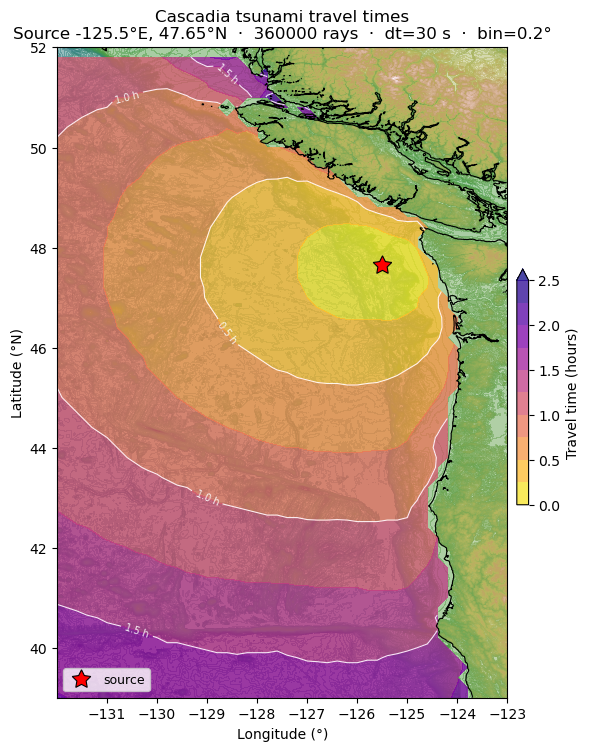

In [13]:
fig, ax = plt.subplots(figsize=(6, 9))

# Full-resolution bathymetry background
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))
ax.contourf(lon_full, lat_full, depth_grid,
            levels=200, cmap='gist_earth', norm=norm, alpha=0.5)
ax.contour(lon_full, lat_full, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Travel time — filled contours on the coarser BIN_DEG grid
tt_max = MAX_TIME / 3600
cf = ax.contourf(lon_bin, lat_bin, travel_time,
                 levels=np.arange(0, tt_max + 0.25, 0.25),
                 cmap='plasma_r', alpha=0.75, extend='max')

# Isochrone lines every 30 minutes
cs = ax.contour(lon_bin, lat_bin, travel_time,
                levels=np.arange(0.5, tt_max + 0.5, 0.5),
                colors='white', linewidths=0.8, alpha=0.9)
ax.clabel(cs, fmt='%.1f h', fontsize=7, inline=True)

# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'Cascadia tsunami travel times\n'
    f'Source {SOURCE_LON}°E, {SOURCE_LAT}°N  ·  '
    f'{len(AZIMUTHS_DEG)} rays  ·  dt={DT:.0f} s  ·  bin={BIN_DEG}°'
)
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='lower left')

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Travel time (hours)')

plt.tight_layout()
plt.show()

Perfect!